# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Tangaran, Grisby Paul James
- _Student No._: 2024-02777
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->
### Problem 1: Resistor Ladder
![Voltage Distribution Line Graph for 10000 nodes](5-problem1-10k.png)

Figure 1. Voltage Distribution Line Graph for 10000 nodes

![Voltage Distribution Line Graphs for varied number of nodes](5-problem1-vary.png)

Figure 2. Voltage Distribution Line Graphs for varied number of nodes

The two graphs show how voltage drops across the resistor ladder network. 
For figure 1, this shows what happens when there are 10000 junction points. The voltage starts at 5 volts at the beginning then slowly drops all the way down toward 0 volts at the end. The drop on the plot looks linear.
For Figure 2, this compares small and large junction numbers from 10 to 10000,. For the smaller number of junctions, the voltage drops to zero almost instatly, looking like steep lines right at the start. When the chain is stretched to 10000 nodes, the voltage drop spreads out across the entire graph, showing how adding more resistors stretches out the voltage drop.

### Other comments
- None


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import banded as bd

In [3]:
V_plus = 5.0
N_1 = 6

A_1 = np.zeros((N_1, N_1))
w_1 = np.zeros(N_1)
w_1[0] = V_plus
w_1[1] = V_plus
for i in range(N_1):
    if i==0 or i == N_1-1:
        A_1[i][i] = 3.0
    else:
        A_1[i][i] = 4.0

    for j in [i-2, i-1, i+1, i+2]:
        if 0<=j <N_1:
            A_1[i,j] = -1
v_1 = np.linalg.solve(A_1, w_1)    

print("A = ", A_1)
print("w = ", w_1)
print("Voltages for N = 6 internal junctions:")
for i in range(len(v_1)):
    voltage = v_1[i]
    print(f" V_{i+1} = {voltage:.4f} V")


A =  [[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]
w =  [5. 5. 0. 0. 0. 0.]
Voltages for N = 6 internal junctions:
 V_1 = 3.7255 V
 V_2 = 3.4314 V
 V_3 = 2.7451 V
 V_4 = 2.2549 V
 V_5 = 1.5686 V
 V_6 = 1.2745 V


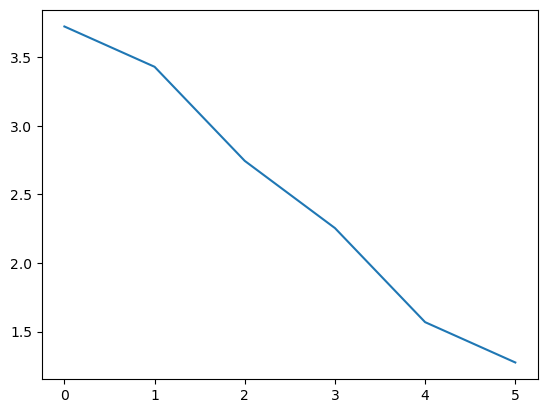

In [19]:
plt.plot(v_1)

In [4]:
N=10000
bd_A = np.zeros((5,N))
bd_A[2,:]=4
bd_A[2,0]=3
bd_A[2, N-1] = 3
bd_A[1, 1:] = -1
bd_A [0,2:] = -1
bd_A [3, :-1] = -1
bd_A[4, :-2] = -1

bd_w= np.zeros(N)
bd_w[0] = 5
bd_w[1] = 5

bd_V = bd.banded(bd_A, bd_w, 2, 2)
print("V1 = ", bd_V[0])


V1 =  4.998882277727716


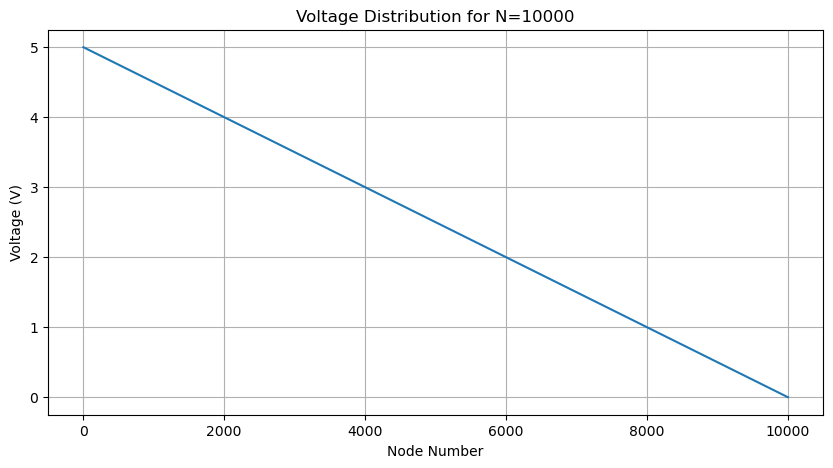

In [17]:
nodes = np.arange(1, N+1)
plt.figure(figsize=(10,5))
plt.plot(nodes, bd_V)
plt.xlabel("Node Number")
plt.ylabel("Voltage (V)")
plt.title("Voltage Distribution for N=10000")
plt.grid()
plt.savefig('5-problem1-10k.png')
plt.show()

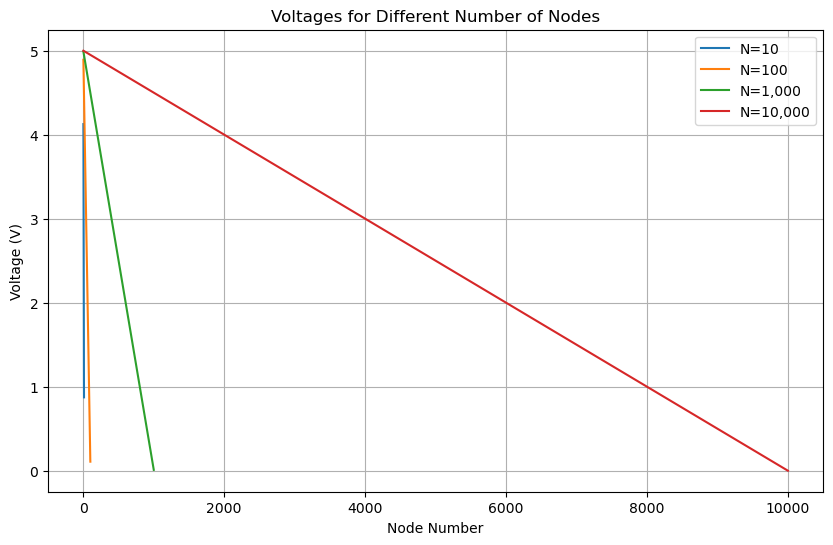

In [16]:
V = {}

for N in [10, 100, 1000, 10000]:
    A_bd=np.zeros((5, N))
    
    A_bd[2, :] = 4
    A_bd[2, 0] = 3
    A_bd[2, N-1] = 3

    A_bd[1, 1:] = -1
    A_bd[0, 2:] = -1
    A_bd[3, :-1] = -1
    A_bd[4, :-2] = -1

    w_bd = np.zeros(N)
    w_bd[0] = 5
    w_bd[1] = 5

    V[N] = bd.banded(A_bd, w_bd, 2, 2)
"""
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)
for ax, N in zip(axes.flat, [10, 100, 1000, 10000]):
    ax.plot(np.arange(1, N+1), V[N])
    ax.set_title(f"N={N:,}")
    ax.set_xlabel("Node Number")
    ax.set_ylabel("Voltage (V)")
    ax.grid()

plt.suptitle("Voltages for Different Number of Nodes", fontsize = 16)
plt.tight_layout()
plt.show()
"""
plt.figure(figsize=(10,6))
for N in [10, 100, 1000, 10000]:
    plt.plot(np.arange(1, N+1), V[N], label = f"N={N:,}")

plt.xlabel("Node Number")
plt.ylabel("Voltage (V)")
plt.title("Voltages for Different Number of Nodes")
plt.legend()
plt.grid()
plt.savefig('5-problem1-vary.png')
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* This code applies Kirchoff's Current Law at each resistor ladder junction to convert the circuit into a system of linear equations, which are solved using numpy's np.linalg.solve for N = 6 and Mark Newman's O(N) banded solver for N = 10000. The code employsd np.zeros and compressed 5xN banded matrix to solve the circuits pentadiagonal equations, and it was then graph with line graph with different number of nodes to visualize differences.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])